In [ ]:
# Data Link:https://www.kaggle.com/datasets/mohammadtalib786/retail-sale-dataset

In [ ]:
import pandas as pd
df=pd.read_csv("/content/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df['Product Category'].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [ ]:
freq_table = df['Product Category'].value_counts().reset_index()
freq_table.columns = ['Product Category', 'Frequency']

freq_table

,Product Category,Frequency
0,Clothing,351
1,Electronics,342
2,Beauty,307


In [ ]:
freq_table['Percentage'] = (freq_table['Frequency'] / freq_table['Frequency'].sum()) * 100

freq_table

,Product Category,Frequency,Percentage
0,Clothing,351,35.1
1,Electronics,342,34.2
2,Beauty,307,30.7


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df.groupby(df['Date'].dt.month)['Total Amount'].sum()

,Total Amount
Date,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


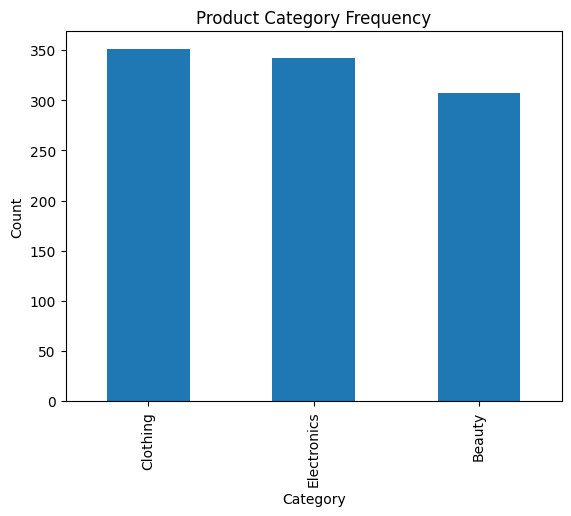

In [ ]:
import matplotlib.pyplot as plt

freq_table = df['Product Category'].value_counts()

freq_table.plot(kind='bar')
plt.title("Product Category Frequency")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

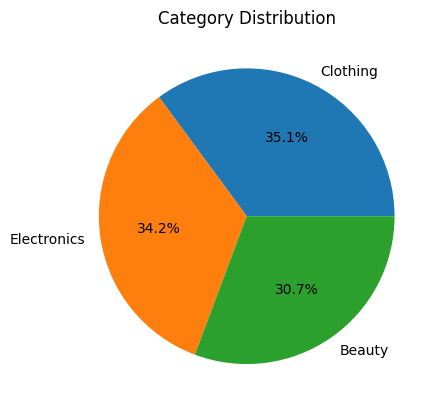

In [ ]:
freq_table.plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Distribution")
plt.ylabel("")
plt.show()

<Axes: xlabel='Gender'>

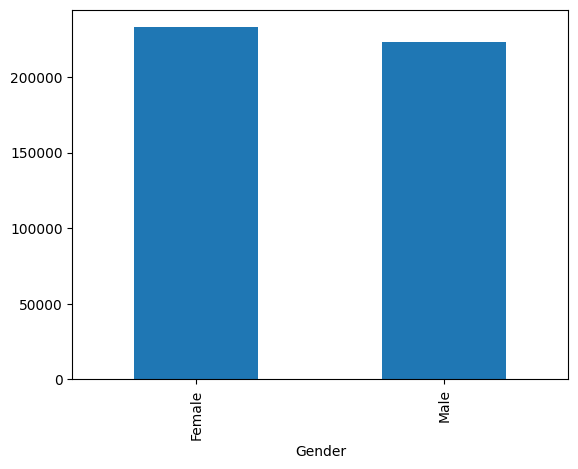

In [ ]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar')

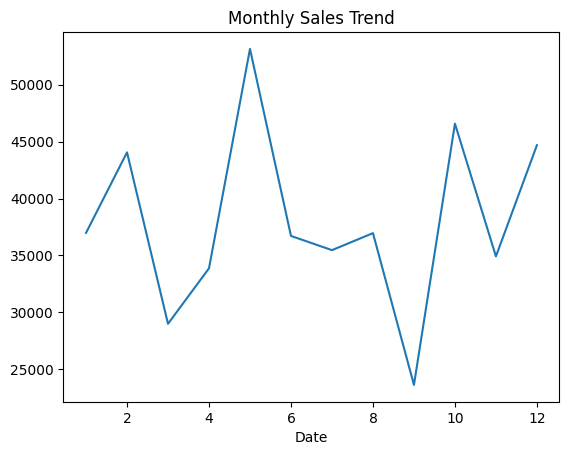

In [ ]:
df.groupby(df['Date'].dt.month)['Total Amount'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

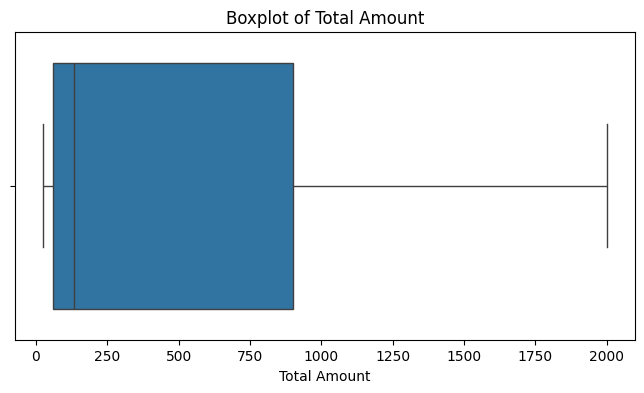

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Total Amount'])

plt.title("Boxplot of Total Amount")
plt.xlabel("Total Amount")

plt.show()

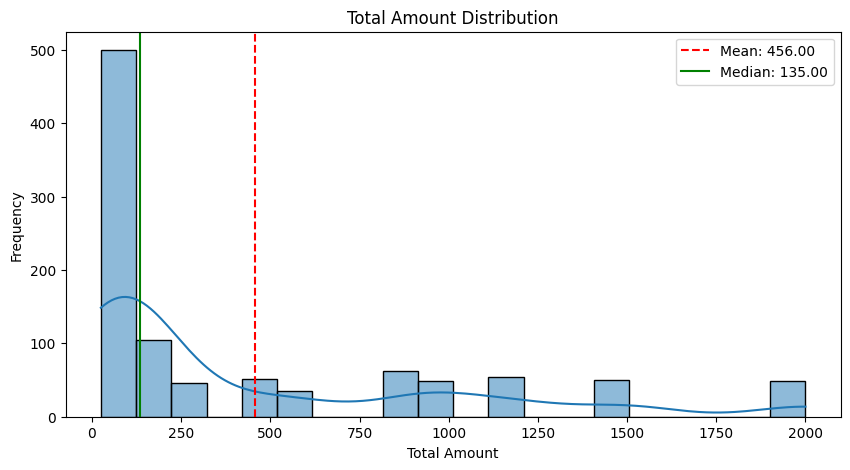

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_val = df['Total Amount'].mean()
median_val = df['Total Amount'].median()

plt.figure(figsize=(10,5))

sns.histplot(df['Total Amount'], bins=20, kde=True)

# Mean line
plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")

# Median line
plt.axvline(median_val, color='green', linestyle='-', label=f"Median: {median_val:.2f}")

plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.legend()
plt.show()

In [ ]:
mean_val = df['Total Amount'].mean()
median_val = df['Total Amount'].median()
mode_val = df['Total Amount'].mode()[0]

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")

if mean_val > median_val:
    print("Distribution: Right Skewed (Mean > Median)")
elif mean_val < median_val:
    print("Distribution: Left Skewed (Mean < Median)")
else:
    print("Distribution: Symmetrical")

print(f"Mode: {mode_val}")

print("\nInsight: The distribution indicates that most transactions are low, with a few high-value purchases.")

Mean: 456.0
Median: 135.0
Distribution: Right Skewed (Mean > Median)
Mode: 50

Insight: The distribution indicates that most transactions are low, with a few high-value purchases.


In [ ]:
import numpy as np

data = df['Total Amount']

# Range
min_val = data.min()
max_val = data.max()
range_val = max_val - min_val
print(f"Range = {max_val} - {min_val} = {range_val}")

Range = 2000 - 25 = 1975


In [ ]:
# Quartiles
Q1 = data.quantile(0.25)
median = data.median()
Q3 = data.quantile(0.75)

# IQR
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Median = {median}")
print(f"Q3 = {Q3}")

print(f"IQR = {Q3} - {Q1} = {IQR}")

Q1 = 60.0
Median = 135.0
Q3 = 900.0
IQR = 900.0 - 60.0 = 840.0


In [ ]:
# Standard Deviation
std_dev = data.std()

print(f"Standard Deviation ≈ {std_dev:.2f}")

Standard Deviation ≈ 560.00


In [ ]:
from scipy import stats
t_stat, p_value = stats.ttest_1samp(df['Total Amount'], 100)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 20.10
P-value: 0.0000


In [ ]:
prev_mean = df['Total Amount'].mean() - 10

In [ ]:
electronics = df[df['Product Category'] == 'Electronics']['Total Amount']

t_stat, p_value = stats.ttest_1samp(electronics, 80)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 12.34
P-value: 0.0000


In [ ]:
from scipy import stats

# Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(df['Total Amount'], 70)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 21.79722034600858
P-value: 1.7700649498337188e-86


In [ ]:
from scipy import stats
import pandas as pd

female_amounts = df[df['Gender'] == 'Female']['Total Amount']
male_amounts = df[df['Gender'] == 'Male']['Total Amount']

t_stat, p_value = stats.ttest_ind(female_amounts, male_amounts, equal_var=False)  # Welch's t-test

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a significant difference in average purchase amount between females and males.")
else:
    print("Fail to reject H0: No significant difference in average purchase amount between females and males.")

T-statistic: 0.03159971766107415
P-value: 0.9747976108130165
Fail to reject H0: No significant difference in average purchase amount between females and males.
